In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import joblib

I0000 00:00:1775930964.913661   28739 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775930964.963789   28739 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775930967.709133   28739 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [6]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [7]:
x_train = X_train/255.0
x_test = X_test/255.0

In [8]:
n_samples, nx, ny = x_train.shape
x_train2 = x_train.reshape(n_samples, nx*ny)

In [9]:
n_samples, nx, ny = x_test.shape
x_test2 = x_test.reshape(n_samples, nx*ny)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

In [11]:
estimator = [
    ('lr', LogisticRegression(max_iter=200)),
    ('knn', KNeighborsClassifier(n_neighbors=3)),
]
vot_soft = VotingClassifier(estimators=estimator, voting='hard', n_jobs=1)
vot_soft.fit(x_train2, y_train)

KeyboardInterrupt: 

In [ ]:
y_pred_VC = vot_soft.predict(x_test2)
y_pred_VC

array([9, 2, 1, ..., 6, 1, 5], shape=(10000,), dtype=uint8)

In [ ]:
print(accuracy_score(y_pred_VC, y_test)*100)

85.50999999999999


In [ ]:
print("Precision",(accuracy_score(y_pred_VC, y_test) * 100))


Precision 85.50999999999999


In [ ]:
print("Recall",(recall_score(y_pred_VC, y_test,average='macro') * 100))

Recall 86.27760181235813


In [ ]:
print("F1:",(f1_score(y_pred_VC, y_test,average='macro') * 100))

F1: 85.14622329020463


In [ ]:
print(classification_report(y_test, y_pred_VC))

              precision    recall  f1-score   support

           0       0.72      0.92      0.81      1000
           1       0.97      0.97      0.97      1000
           2       0.66      0.86      0.75      1000
           3       0.87      0.85      0.86      1000
           4       0.78      0.72      0.75      1000
           5       0.95      0.95      0.95      1000
           6       0.80      0.46      0.58      1000
           7       0.92      0.96      0.94      1000
           8       0.99      0.92      0.95      1000
           9       0.97      0.93      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.85     10000
weighted avg       0.86      0.86      0.85     10000



In [ ]:
joblib.dump(vot_soft, 'voting_classifier_model.pkl')

['voting_classifier_model.pkl']

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import six
import sys
sys.modules['sklearn.externals.six'] = six
from mlxtend.classifier import StackingClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
gnb = GaussianNB()

In [ ]:
model_KNC = knn.fit(x_train2, y_train)

In [ ]:
pred_knc = model_KNC.predict(x_test2)

In [ ]:
print("Neighbors Classifier Accuracy:", accuracy_score(pred_knc, y_test)*100)

Neighbors Classifier Accuracy: 85.41


In [ ]:
lr = LogisticRegression(solver='saga', max_iter=200)
clf_stack = StackingClassifier(classifiers=[knn, gnb], meta_classifier=lr, use_probas=True, use_features_in_secondary=False)

In [ ]:
model_stack = clf_stack.fit(x_train2, y_train)

In [ ]:
ypred_stack = model_stack.predict(x_test2)

In [ ]:
print("Stacking Classifier Accuracy:", accuracy_score(ypred_stack, y_test)*100)


Stacking Classifier Accuracy: 86.41


In [ ]:
print("Stacking Precision:",(precision_score(ypred_stack, y_test,average='macro') * 100))

Stacking Precision: 86.41


In [ ]:
print("Stacking f1_score:",(f1_score(ypred_stack, y_test,average='macro') * 100))


Stacking f1_score: 86.45527707361865


In [ ]:
joblib.dump(clf_stack, 'stacking_classifier_model1.pkl')

['stacking_classifier_model1.pkl']

ADA BOOST

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators=50, learning_rate=1,random_state=0)

In [ ]:
ada.fit(x_train2, y_train)

NameError: name 'x_train2' is not defined

In [ ]:
y_pred_ada = ada.predict(x_test2)
y_pred_ada

array([5, 2, 1, ..., 8, 1, 5], shape=(10000,), dtype=uint8)

Predicted Label: [5]
Actual Label: 5


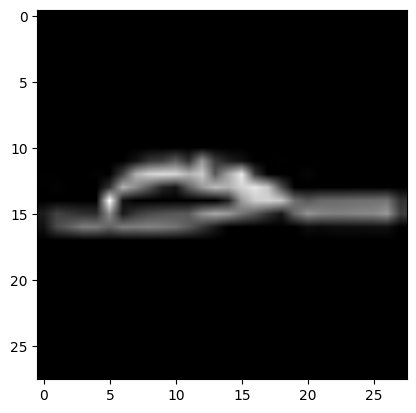

In [ ]:
pre = x_test[8].reshape(1, -1)
y_pred_2 = vot_soft.predict(pre)

p = plt.subplot(1, 1, 1)
plt.imshow(x_test[8], cmap=plt.cm.gray, interpolation='bilinear')

print("Predicted Label:", y_pred_2)
print("Actual Label:", y_test[8])

STACKING CLASSIFIER

Predicted Label: [5]
Actual Label: 5


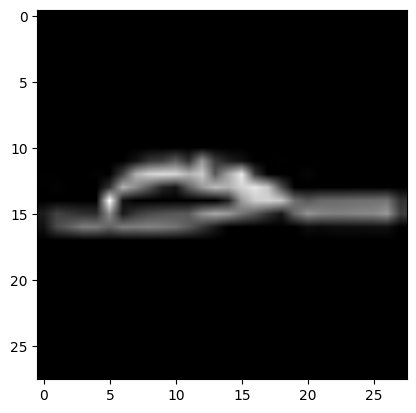

In [ ]:
pre = x_test[8].reshape(1, -1)
y_pred_2 = model_stack.predict(pre)

p = plt.subplot(1, 1, 1)
plt.imshow(x_test[8], cmap=plt.cm.gray, interpolation='bilinear')

print("Predicted Label:", y_pred_2)
print("Actual Label:", y_test[8])

Predicted Label: [5]
Actual Label: 5


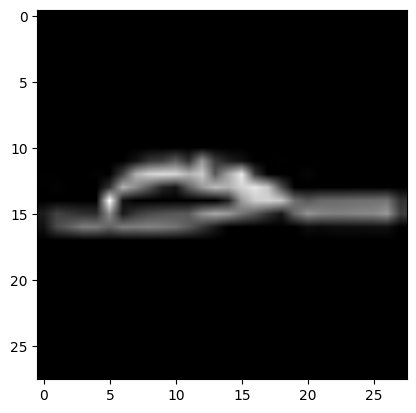

In [ ]:
pre = x_test[8].reshape(1, -1)
y_pred_2 = vot_soft.predict(pre)

p = plt.subplot(1, 1, 1)
plt.imshow(x_test[8], cmap=plt.cm.gray, interpolation='bilinear')

print("Predicted Label:", y_pred_2)
print("Actual Label:", y_test[8])

# Create,train and predict adaboost classifer object with SVM

In [ ]:
from sklearn.svm import SVC
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
svc=SVC(probability=True, kernel='linear')

In [ ]:
abc = AdaBoostClassifier(n_estimators=10, estimator=svc, learning_rate=1)







NameError: name 'AdaBoostClassifier' is not defined

In [ ]:
# Train Adaboost Classifer
model = abc.fit(x_train2, y_train)

In [ ]:
#Predict the response for test dataset
y_pred = model.predict(x_test2)